In [2]:
# Beta calculations (pairwise vs multi-factor rolling OLS)

import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS


C:\Users\lysla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tools\tools.py:6: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  import scipy.linalg


In [3]:
# Load + merge data (edit filenames/columns if yours differ)

df_equity = pd.read_csv("All_Equities_Cleaned.csv", parse_dates=["Dates"]).set_index("Dates")
df_mkt    = pd.read_csv("MSCI_Data.csv", parse_dates=["Date"]).set_index("Date")

# Inner join on dates so everything lines up
df = df_mkt.join(df_equity, how="inner").sort_index()

df.head()


,MSCI USA,MSCI USA Value,MSCI USA Low Size,MSCI USA Low Volatility,MSCI USA High Dividend Yield,MSCI USA Quality,MSCI USA Momentum,KATE US Equity,KBH US Equity,KDP US Equity,...,CTSH UW Equity,CTVA US Equity,CTXS UQ Equity,CTXS UW Equity,CVC US Equity,CVG US Equity,CVH US Equity,CVS US Equity,CVX US Equity,CXO US Equity
1999-01-29,2673.05,3277.734545,2384.21,995.479542,997.649417,683.831934,512.942863,19.0938,14.0938,NaN,...,0.8099,NaN,18.0409,18.0409,33.0573,18.0000,4.3333,27.3750,37.2500,NaN
1999-02-26,2598.02,3251.106568,2391.18,969.079546,970.419053,658.588413,500.178311,16.8438,11.2500,NaN,...,0.8958,NaN,15.3534,15.3534,31.8920,17.3125,4.7639,26.5000,38.4375,NaN
1999-03-31,2705.67,3332.419537,2344.66,989.782505,967.408227,682.563547,528.966699,16.3125,11.2813,NaN,...,0.5781,NaN,15.1793,15.1793,36.3692,17.1250,3.3333,23.7500,44.3750,NaN
1999-04-30,2802.00,3624.972158,2410.24,1033.753199,1064.030284,688.421002,530.437255,16.5313,12.1563,NaN,...,0.4674,NaN,16.9211,16.9211,37.9638,18.5625,4.0833,23.8125,49.8750,NaN
1999-05-31,2736.32,3560.597835,2663.08,1024.310711,1045.278656,672.911109,515.715429,18.0000,12.0625,NaN,...,0.5234,NaN,19.6833,19.6833,38.6997,17.6250,5.8889,23.0000,46.2500,NaN


In [4]:
# Monthly returns (simple returns). If your inputs are already returns, skip this.
returns = df.pct_change()

# Keep only rows where factor data exist (equities can still have NaNs; we'll handle per-window)
returns = returns.sort_index()

returns.tail()


C:\Users\lysla\AppData\Local\Temp\ipykernel_2588\1469708139.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change()


,MSCI USA,MSCI USA Value,MSCI USA Low Size,MSCI USA Low Volatility,MSCI USA High Dividend Yield,MSCI USA Quality,MSCI USA Momentum,KATE US Equity,KBH US Equity,KDP US Equity,...,CTSH UW Equity,CTVA US Equity,CTXS UQ Equity,CTXS UW Equity,CVC US Equity,CVG US Equity,CVH US Equity,CVS US Equity,CVX US Equity,CXO US Equity
2019-08-30,-0.018049,-0.026861,0.010797,0.016076,-0.009338,-0.014676,0.002347,0.0,0.069281,-0.030561,...,-0.057568,-0.006102,-0.013370,-0.013370,0.0,0.0,0.0,0.090388,-0.043782,-0.251126
2019-09-30,0.017349,0.034457,-0.033485,0.008429,0.035550,0.013117,-0.012455,0.0,0.210395,0.001466,...,-0.018325,-0.045020,0.038073,0.038073,0.0,0.0,0.0,0.035292,0.007475,-0.071770
2019-10-31,0.021415,0.013770,0.025596,-0.002028,0.006769,0.030015,0.005914,0.0,0.049706,0.030747,...,0.011201,-0.057857,0.127849,0.127849,0.0,0.0,0.0,0.052640,-0.020742,-0.005596
2019-11-29,0.036941,0.029028,0.013026,0.012616,0.019885,0.043017,0.033299,0.0,-0.031101,0.098722,...,0.052018,-0.013647,0.036285,0.036285,0.0,0.0,0.0,0.133755,0.008524,0.074645
2019-12-31,0.028843,0.027223,0.037166,0.018243,0.022616,0.036333,0.017539,0.0,-0.008965,-0.064318,...,-0.032600,0.136049,-0.016931,-0.016931,0.0,0.0,0.0,-0.013020,0.028857,0.206863


In [5]:
# Factors (targets) + equities
factors = [
    "MSCI USA",
    "MSCI USA Value",
    "MSCI USA Low Size",
    "MSCI USA Low Volatility",
    "MSCI USA High Dividend Yield",
    "MSCI USA Quality",
    "MSCI USA Momentum",
]

# Anything that's not a factor is treated as an equity column.
exclude = set(factors) | {"RF_Rate"}
equities = [c for c in returns.columns if c not in exclude]

print(f"Rows in returns: {len(returns):,}")
print(f"Equity columns:  {len(equities):,}")
print(f"Factor columns:  {len(factors):,}")


Rows in returns: 252
Equity columns:  1,152
Factor columns:  7


In [6]:
def rolling_pairwise_beta(returns: pd.DataFrame, equity: str, factor: str, window: int = 60) -> pd.Series:
    """Rolling pairwise beta: Cov(R_e, R_f) / Var(R_f)."""
    cov = returns[equity].rolling(window).cov(returns[factor])
    var = returns[factor].rolling(window).var()
    return cov / var


def pairwise_betas_all(returns: pd.DataFrame, equities: list[str], factors: list[str], window: int = 60) -> dict[str, pd.DataFrame]:
    """All pairwise rolling betas for each equity vs each factor."""
    out = {}
    rolling_var = returns[factors].rolling(window).var()  # compute once

    for eq in equities:
        betas = pd.DataFrame(index=returns.index)
        for f in factors:
            cov = returns[eq].rolling(window).cov(returns[f])
            betas[f"beta_{f}"] = cov / rolling_var[f]
        out[eq] = betas
    return out


In [7]:
def rolling_multifactor_betas(
    returns: pd.DataFrame,
    equity: str,
    factors: list[str],
    window: int = 60,
    min_window: int = 36,
) -> dict[str, object]:
    """
    Rolling multi-factor OLS:
        r_e,t = alpha_t + b_t' f_t + eps_t

    Returns:
      - params:  DataFrame of rolling coefficients (const + factors)
      - pvalues: DataFrame of rolling p-values (same shape as params)
      - r2:      Series of rolling R^2 at each window endpoint

    Notes:
    - Drops rows with NaNs in equity or factors.
    - If not enough data, returns empty outputs.
    """
    df = pd.concat([returns[[equity]], returns[factors]], axis=1).dropna()
    if len(df) < min_window:
        return {
            "params": pd.DataFrame(),
            "pvalues": pd.DataFrame(),
            "r2": pd.Series(dtype=float),
        }

    y = df[equity]
    X = sm.add_constant(df[factors], has_constant="add")

    w = min(window, len(df))
    if w < min_window:
        return {
            "params": pd.DataFrame(),
            "pvalues": pd.DataFrame(),
            "r2": pd.Series(dtype=float),
        }

    res = RollingOLS(y, X, window=w, min_nobs=w).fit()

    params = pd.DataFrame(res.params, index=X.index, columns=X.columns)
    pvals  = pd.DataFrame(res.pvalues, index=X.index, columns=X.columns)
    r2     = pd.Series(res.rsquared, index=X.index)
    
    avg_r2_clean = r2.replace([np.inf, -np.inf], np.nan).dropna()

    # RollingOLS produces NaNs before the first full window; keep them (or drop later)
    return {"params": params, "pvalues": pvals, "r2": avg_r2_clean}


In [8]:
# Run pairwise betas (all equities). 
WINDOW = 60

pairwise = pairwise_betas_all(returns, equities, factors, window=WINDOW)

# Quick sanity check for one equity
sample_eq = equities[0]
pairwise[sample_eq].dropna().tail()


,beta_MSCI USA,beta_MSCI USA Value,beta_MSCI USA Low Size,beta_MSCI USA Low Volatility,beta_MSCI USA High Dividend Yield,beta_MSCI USA Quality,beta_MSCI USA Momentum
2019-08-30,0.620214,0.698804,0.163025,1.098549,0.918462,0.578807,0.423694
2019-09-30,0.560739,0.634477,0.239905,1.023991,0.862553,0.528634,0.371637
2019-10-31,0.553807,0.628642,0.259163,1.017479,0.856121,0.519696,0.365868
2019-11-29,0.506752,0.597186,0.213240,0.920305,0.796731,0.483820,0.297042
2019-12-31,0.507241,0.596083,0.212599,0.922519,0.800007,0.483721,0.301023


In [ ]:
for sample in pairwise[sample_eq].columns:
    print(f"{sample}: {pairwise[sample_eq][sample].dropna().tail(3)}")

beta_MSCI USA: 2019-10-31    0.553807
2019-11-29    0.506752
2019-12-31    0.507241
Name: beta_MSCI USA, dtype: float64
beta_MSCI USA Value: 2019-10-31    0.628642
2019-11-29    0.597186
2019-12-31    0.596083
Name: beta_MSCI USA Value, dtype: float64
beta_MSCI USA Low Size: 2019-10-31    0.259163
2019-11-29    0.213240
2019-12-31    0.212599
Name: beta_MSCI USA Low Size, dtype: float64
beta_MSCI USA Low Volatility: 2019-10-31    1.017479
2019-11-29    0.920305
2019-12-31    0.922519
Name: beta_MSCI USA Low Volatility, dtype: float64
beta_MSCI USA High Dividend Yield: 2019-10-31    0.856121
2019-11-29    0.796731
2019-12-31    0.800007
Name: beta_MSCI USA High Dividend Yield, dtype: float64
beta_MSCI USA Quality: 2019-10-31    0.519696
2019-11-29    0.483820
2019-12-31    0.483721
Name: beta_MSCI USA Quality, dtype: float64
beta_MSCI USA Momentum: 2019-10-31    0.365868
2019-11-29    0.297042
2019-12-31    0.301023
Name: beta_MSCI USA Momentum, dtype: float64


In [13]:
pairwise

{'KATE US Equity':             beta_MSCI USA  beta_MSCI USA Value  beta_MSCI USA Low Size  \
 1999-01-29            NaN                  NaN                     NaN   
 1999-02-26            NaN                  NaN                     NaN   
 1999-03-31            NaN                  NaN                     NaN   
 1999-04-30            NaN                  NaN                     NaN   
 1999-05-31            NaN                  NaN                     NaN   
 ...                   ...                  ...                     ...   
 2019-08-30       0.620214             0.698804                0.163025   
 2019-09-30       0.560739             0.634477                0.239905   
 2019-10-31       0.553807             0.628642                0.259163   
 2019-11-29       0.506752             0.597186                0.213240   
 2019-12-31       0.507241             0.596083                0.212599   
 
             beta_MSCI USA Low Volatility  beta_MSCI USA High Dividend Yield  \


In [ ]:
# Run multi-factor rolling OLS betas (loop over equities)

mf = {}
mf_r2 = {}
mf_p = {} 

for eq in equities:
    out = rolling_multifactor_betas(returns, eq, factors, window=WINDOW, min_window=36)
    if out["params"].empty:
        continue
    mf[eq] = out["params"]
    mf_r2[eq] = out["r2"]
    mf_p[eq] = out["pvalues"]       

print(f"Multi-factor betas estimated for: {len(mf):,} / {len(equities):,} equities")


C:\Users\lysla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\regression\rolling.py:272: RuntimeWarning: divide by zero encountered in log
  llf = -np.log(ssr) * nobs2  # concentrated likelihood
C:\Users\lysla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\regression\rolling.py:272: RuntimeWarning: divide by zero encountered in log
  llf = -np.log(ssr) * nobs2  # concentrated likelihood
C:\Users\lysla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\regression\rolling.py:272: RuntimeWarning: divide by zero encountered in log
  llf = -np.log(ssr) * nobs2  # concentrated likelihood
C:\Users\lysla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmode

Multi-factor betas estimated for: 1,137 / 1,152 equities


C:\Users\lysla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\regression\rolling.py:272: RuntimeWarning: divide by zero encountered in log
  llf = -np.log(ssr) * nobs2  # concentrated likelihood


In [ ]:
# --- Small stats output ---

# 1) Pairwise: latest market beta distribution (MSCI USA)
market_col = "beta_MSCI USA"
latest_market_betas = pd.Series(
    {eq: df_beta[market_col].dropna().iloc[-1] for eq, df_beta in pairwise.items() if df_beta[market_col].dropna().shape[0] > 0},
    name="latest_beta_mkt"
).dropna()

print("Pairwise (latest) MSCI USA beta summary:")
print(latest_market_betas.describe())

# 2) Multi-factor: average R^2 per equity (rolling endpoint average)
avg_r2 = pd.Series({eq: r2.mean() for eq, r2 in mf_r2.items() if len(r2) > 0}).dropna().sort_values(ascending=False)

print("\nMulti-factor rolling OLS: average R^2 summary:")
print(avg_r2.describe())

print("\nTop 10 equities by average R^2:")
display(avg_r2.head(10).to_frame("avg_R2"))

# 3) Show the most recent multi-factor betas + p-values for one equity (example)
example_eq = avg_r2.index[100] if len(avg_r2) else sample_eq

params_df = mf[example_eq].dropna()
pvals_df  = mf_p[example_eq]

last_dt = params_df.index.intersection(pvals_df.index).max()

latest_betas = params_df.loc[last_dt]
latest_pvals = pvals_df.loc[last_dt]

latest_table = pd.DataFrame({
    "beta": latest_betas,
    "p_value": latest_pvals
}).sort_values("p_value")

def sig_stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

latest_table2 = latest_table.copy()
latest_table2["beta"] = latest_table2["beta"].map(lambda x: f"{x:.4f}")
latest_table2["p_value"] = latest_table2["p_value"].map(lambda x: f"{x:.4g}")
latest_table2["sig"] = latest_table["p_value"].astype(float).map(sig_stars)

print(f"\nMost recent betas (with significance) for: {example_eq}")
display(latest_table2)


Pairwise (latest) MSCI USA beta summary:
count    1119.000000
mean        0.695644
std         0.685428
min        -2.249968
25%         0.000000
50%         0.662413
75%         1.191242
max         3.559447
Name: latest_beta_mkt, dtype: float64

Multi-factor rolling OLS: average R^2 summary:
count    1136.000000
mean        0.369155
std         0.134673
min         0.035813
25%         0.277473
50%         0.378549
75%         0.466715
max         0.760328
dtype: float64

Top 10 equities by average R^2:


,avg_R2
AMP US Equity,0.760328
CFG US Equity,0.751148
JPM US Equity,0.736480
MS US Equity,0.706667
IVZ US Equity,0.697513
PRU US Equity,0.695306
MET US Equity,0.689674
LNC US Equity,0.688660
C US Equity,0.686098
HON US Equity,0.685446



Most recent betas (with significance) for: EMN US Equity


,beta,p_value,sig
MSCI USA Low Volatility,-3.3091,4.971e-08,***
MSCI USA High Dividend Yield,2.7149,0.005381,***
MSCI USA,4.5764,0.02003,**
MSCI USA Quality,-1.6732,0.06377,*
MSCI USA Low Size,-0.2742,0.08023,*
MSCI USA Value,-1.8133,0.236,
const,0.0046,0.4563,
MSCI USA Momentum,0.0085,0.9884,


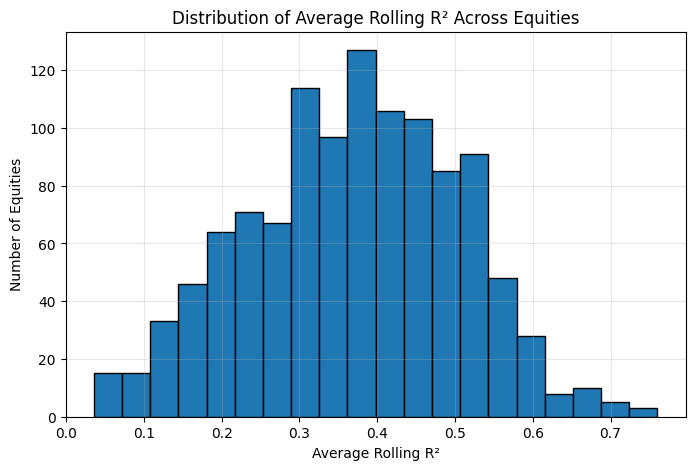

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(avg_r2, bins=20, edgecolor="black")
plt.title("Distribution of Average Rolling R² Across Equities")
plt.xlabel("Average Rolling R²")
plt.ylabel("Number of Equities")
plt.grid(alpha=0.3)

plt.show()